<a href="https://colab.research.google.com/github/TitanStriker99/ai-jupyter-lab/blob/main/cybersecurity_asset_triage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cybersecurity Asset Triage

## Purpose

This notebook demonstrates a basic cybersecurity asset-triage workflow using fictional data.

The notebook uses Python to:

- Review a fictional device inventory
- Identify systems that may require security attention
- Check patch age
- Check encryption status
- Check antivirus/endpoint protection status
- Assign reasons for security review
- Practice debugging and interpreting Python errors


In [1]:
devices = [
    {
        "name": "SEC-WS-01",
        "type": "Security Analyst Workstation",
        "os": "Windows 11",
        "days_since_patch": 12,
        "encrypted": True,
        "antivirus_installed": True,
        "owner_team": "Security Operations"
    },
    {
        "name": "HR-LAPTOP-04",
        "type": "Laptop",
        "os": "Windows 11",
        "days_since_patch": 47,
        "encrypted": True,
        "antivirus_installed": True,
        "owner_team": "Human Resources"
    },
    {
        "name": "LEGACY-WS-03",
        "type": "Workstation",
        "os": "Windows 10",
        "days_since_patch": 95,
        "encrypted": False,
        "antivirus_installed": True,
        "owner_team": "Operations"
    },
    {
        "name": "FILE-SERVER-01",
        "type": "Server",
        "os": "Windows Server",
        "days_since_patch": 160,
        "encrypted": True,
        "antivirus_installed": True,
        "owner_team": "IT Infrastructure"
    },
    {
        "name": "DEV-LINUX-02",
        "type": "Development Server",
        "os": "Ubuntu Linux",
        "days_since_patch": 22,
        "encrypted": True,
        "antivirus_installed": False,
        "owner_team": "Development"
    }
]

print(f"Loaded {len(devices)} fictional cybersecurity assets.")

Loaded 5 fictional cybersecurity assets.


## Understanding the Dataset

The variable `devices` is a Python list.

Each item inside the list is a dictionary representing one fictional computer or server. Each dictionary contains information about the asset, including its operating system, patch status, encryption status, endpoint protection status, and responsible team.

The Boolean values `True` and `False` represent whether a security control is enabled.

The `len()` function counts how many devices are stored in the list.

In [2]:
for device in devices:
    print(
        device["name"],
        "| OS:", device["os"],
        "| Patch Age:", device["days_since_patch"], "days",
        "| Encrypted:", device["encrypted"],
        "| Antivirus:", device["antivirus_installed"]
    )

SEC-WS-01 | OS: Windows 11 | Patch Age: 12 days | Encrypted: True | Antivirus: True
HR-LAPTOP-04 | OS: Windows 11 | Patch Age: 47 days | Encrypted: True | Antivirus: True
LEGACY-WS-03 | OS: Windows 10 | Patch Age: 95 days | Encrypted: False | Antivirus: True
FILE-SERVER-01 | OS: Windows Server | Patch Age: 160 days | Encrypted: True | Antivirus: True
DEV-LINUX-02 | OS: Ubuntu Linux | Patch Age: 22 days | Encrypted: True | Antivirus: False


## Asset Inspection

The `for` loop examines each device in the `devices` list one at a time.

During each iteration, the variable `device` represents one dictionary containing the information for a single asset.

The loop then accesses selected fields from that dictionary and prints them so an analyst can quickly review the inventory.

In [3]:
needs_attention = []

for device in devices:
    reasons = []

    if device["days_since_patch"] > 60:
        reasons.append("Patch age exceeds 60 days")

    if not device["encrypted"]:
        reasons.append("Device is not encrypted")

    if not device["antivirus_installed"]:
        reasons.append("Endpoint protection is not installed")

    if reasons:
        needs_attention.append({
            "name": device["name"],
            "owner_team": device["owner_team"],
            "reasons": reasons
        })

print(f"Devices needing security review: {len(needs_attention)}")

for device in needs_attention:
    print(f"\n{device['name']} ({device['owner_team']})")
    for reason in device["reasons"]:
        print("-", reason)

Devices needing security review: 3

LEGACY-WS-03 (Operations)
- Patch age exceeds 60 days
- Device is not encrypted

FILE-SERVER-01 (IT Infrastructure)
- Patch age exceeds 60 days

DEV-LINUX-02 (Development)
- Endpoint protection is not installed


## Security Triage Rule

For this training exercise, an asset is flagged for additional review when one or more of the following conditions are present:

1. The device has not been patched in more than 60 days.
2. The device is not encrypted.
3. Endpoint protection or antivirus is not installed.

These conditions were selected to demonstrate basic Python filtering and security-control review. They are simplified training rules and should not be interpreted as a complete organizational security policy.

The purpose of triage is to identify systems that deserve additional investigation rather than automatically declaring a system compromised.

In [4]:
encrypted_count = 0
unencrypted_count = 0

for device in devices:
    if device["encrypted"]:
        encrypted_count += 1
    else:
        unencrypted_count += 1

print("Encrypted devices:", encrypted_count)
print("Unencrypted devices:", unencrypted_count)

Encrypted devices: 4
Unencrypted devices: 1


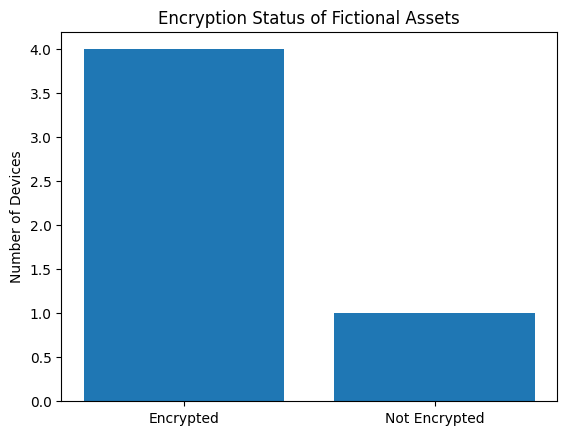

In [5]:
import matplotlib.pyplot as plt

categories = ["Encrypted", "Not Encrypted"]
counts = [encrypted_count, unencrypted_count]

plt.bar(categories, counts)
plt.title("Encryption Status of Fictional Assets")
plt.ylabel("Number of Devices")
plt.show()

### Encryption Status Observation

Most assets in this fictional inventory are encrypted. However, one device lacks encryption and should be reviewed because encryption helps protect stored data if a device is lost, stolen, or accessed without authorization.

In [6]:
print(security_devices)

NameError: name 'security_devices' is not defined

In [7]:
print(devices)

[{'name': 'SEC-WS-01', 'type': 'Security Analyst Workstation', 'os': 'Windows 11', 'days_since_patch': 12, 'encrypted': True, 'antivirus_installed': True, 'owner_team': 'Security Operations'}, {'name': 'HR-LAPTOP-04', 'type': 'Laptop', 'os': 'Windows 11', 'days_since_patch': 47, 'encrypted': True, 'antivirus_installed': True, 'owner_team': 'Human Resources'}, {'name': 'LEGACY-WS-03', 'type': 'Workstation', 'os': 'Windows 10', 'days_since_patch': 95, 'encrypted': False, 'antivirus_installed': True, 'owner_team': 'Operations'}, {'name': 'FILE-SERVER-01', 'type': 'Server', 'os': 'Windows Server', 'days_since_patch': 160, 'encrypted': True, 'antivirus_installed': True, 'owner_team': 'IT Infrastructure'}, {'name': 'DEV-LINUX-02', 'type': 'Development Server', 'os': 'Ubuntu Linux', 'days_since_patch': 22, 'encrypted': True, 'antivirus_installed': False, 'owner_team': 'Development'}]


## What I Learned from an Error

I intentionally referenced a variable named `security_devices` even though that variable had never been defined. Python returned a `NameError`.

I learned that Python variable names must exactly match previously defined variables. Error messages can help identify both the category of the problem and the line that caused it.

## Cybersecurity Findings

The fictional asset inventory contains five systems.

Three assets require additional security review:

- **LEGACY-WS-03** has exceeded the patch threshold and does not have encryption enabled.
- **FILE-SERVER-01** has exceeded the 60-day patch threshold.
- **DEV-LINUX-02** does not have endpoint protection installed.

The results demonstrate how Python can automate repetitive security-review tasks. Instead of manually checking every asset, an analyst can define conditions and automatically identify systems requiring further investigation.

In a real security environment, additional factors could include vulnerability severity, asset criticality, authentication logs, network exposure, configuration compliance, unsupported software, and known vulnerabilities.

No real organizational information, credentials, PII, PHI, or sensitive information was used in this notebook.